# Chapter 9. Plotting and Visualization
- The project was started by John Hunter in 2002 to enable a MATLAB-like plotting interface in Python.

In [1]:
%matplotlib notebook

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 9.1 A Brief matplotlib API Primer

### Figures and Subplots

<IPython.core.display.Javascript object>


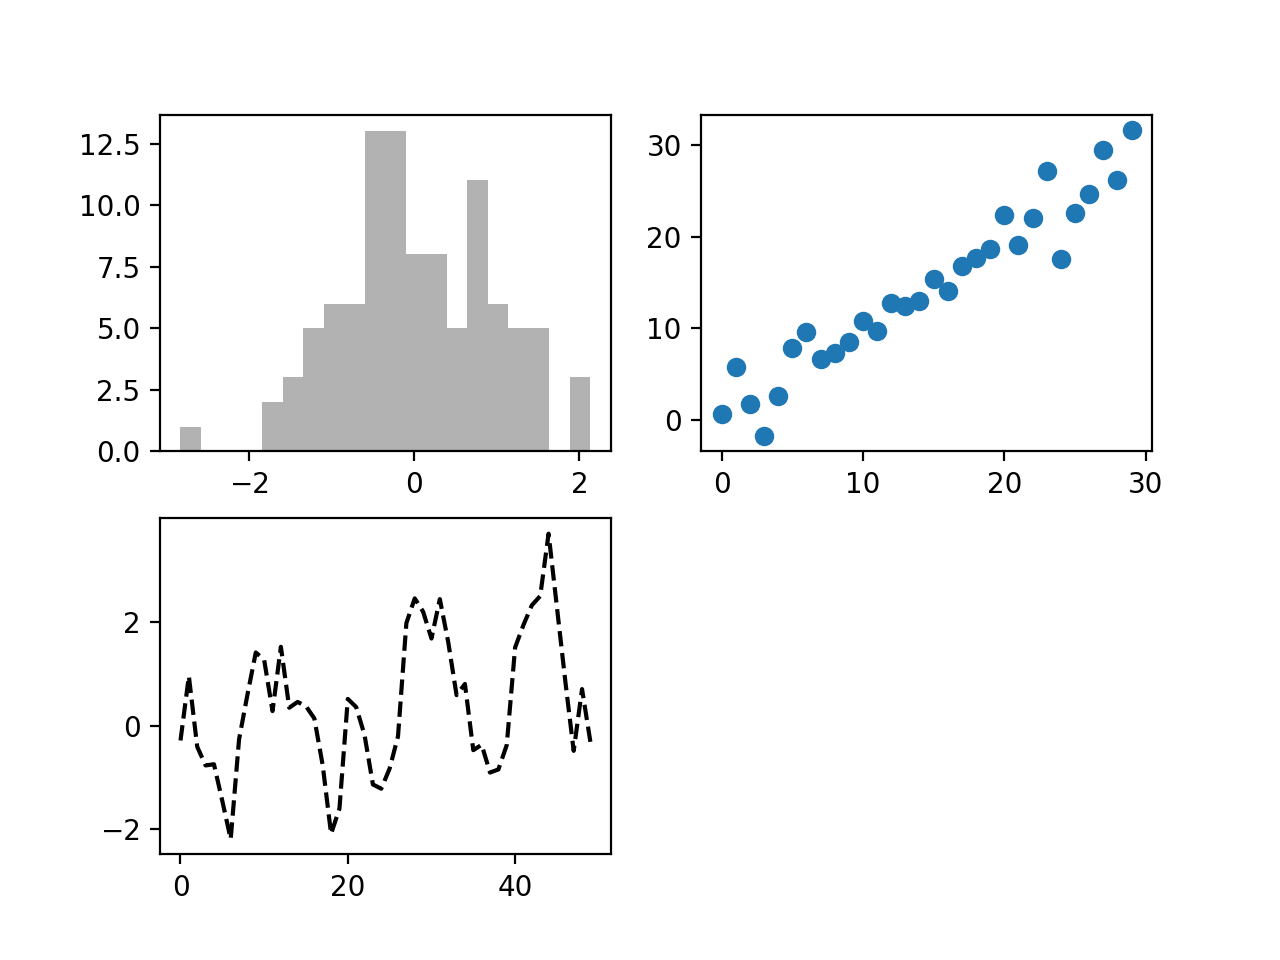

In [29]:
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)

In [30]:
# matplotlib draws on the last figure
plt.plot(np.random.randn(50).cumsum(), 'k--') 

In [31]:
ax1.hist(np.random.randn(100), bins=20, color='k', alpha=0.3)

(array([ 1.,  0.,  0.,  0.,  2.,  3.,  5.,  6.,  6., 13., 13.,  8.,  8.,
         5., 11.,  6.,  5.,  5.,  0.,  3.]),
 array([-2.82995275, -2.5817524 , -2.33355206, -2.08535171, -1.83715137,
        -1.58895102, -1.34075068, -1.09255033, -0.84434998, -0.59614964,
        -0.34794929, -0.09974895,  0.1484514 ,  0.39665174,  0.64485209,
         0.89305244,  1.14125278,  1.38945313,  1.63765347,  1.88585382,
         2.13405416]),
 <BarContainer object of 20 artists>)

In [32]:
ax2.scatter(np.arange(30), np.arange(30)+3*np.random.randn(30))

> - Creating a figure with a grid of subplot is a very common task, so matplotlib includes a convenience method, ***plt.subplots***, that creates a new figure and returns a Numpy array containing the created subplot objects:

<IPython.core.display.Javascript object>


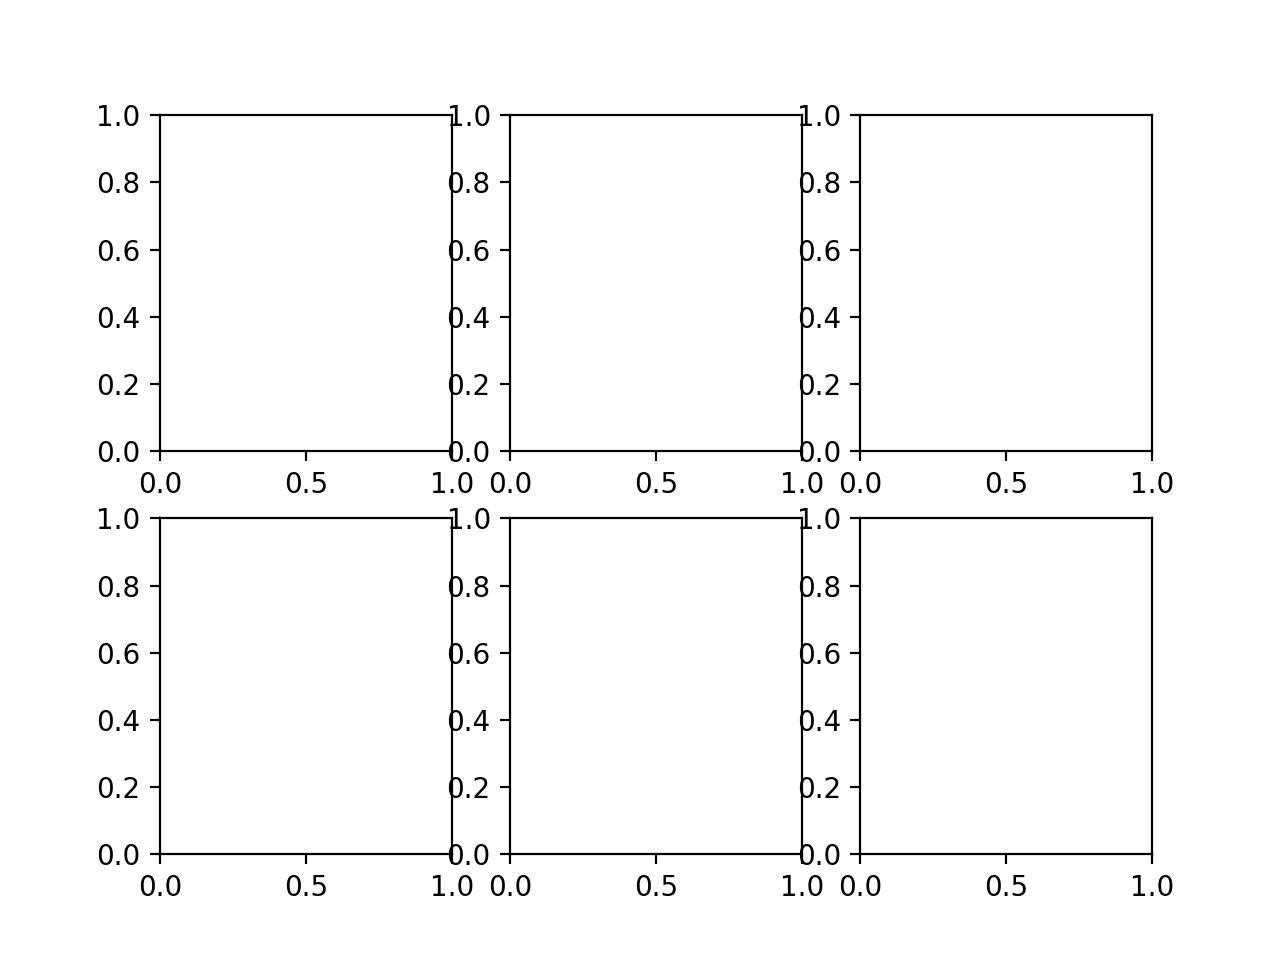

array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>]], dtype=object)

In [34]:
fig, axes = plt.subplots(2,3)
axes

- The axes array can be easily indexed like a two-dimensional array; for example, ***axes[0,1]***
- You can also indicate that subplots should have the same x- or y-axis using ***sharex*** and ***sharey***, respectively.

> 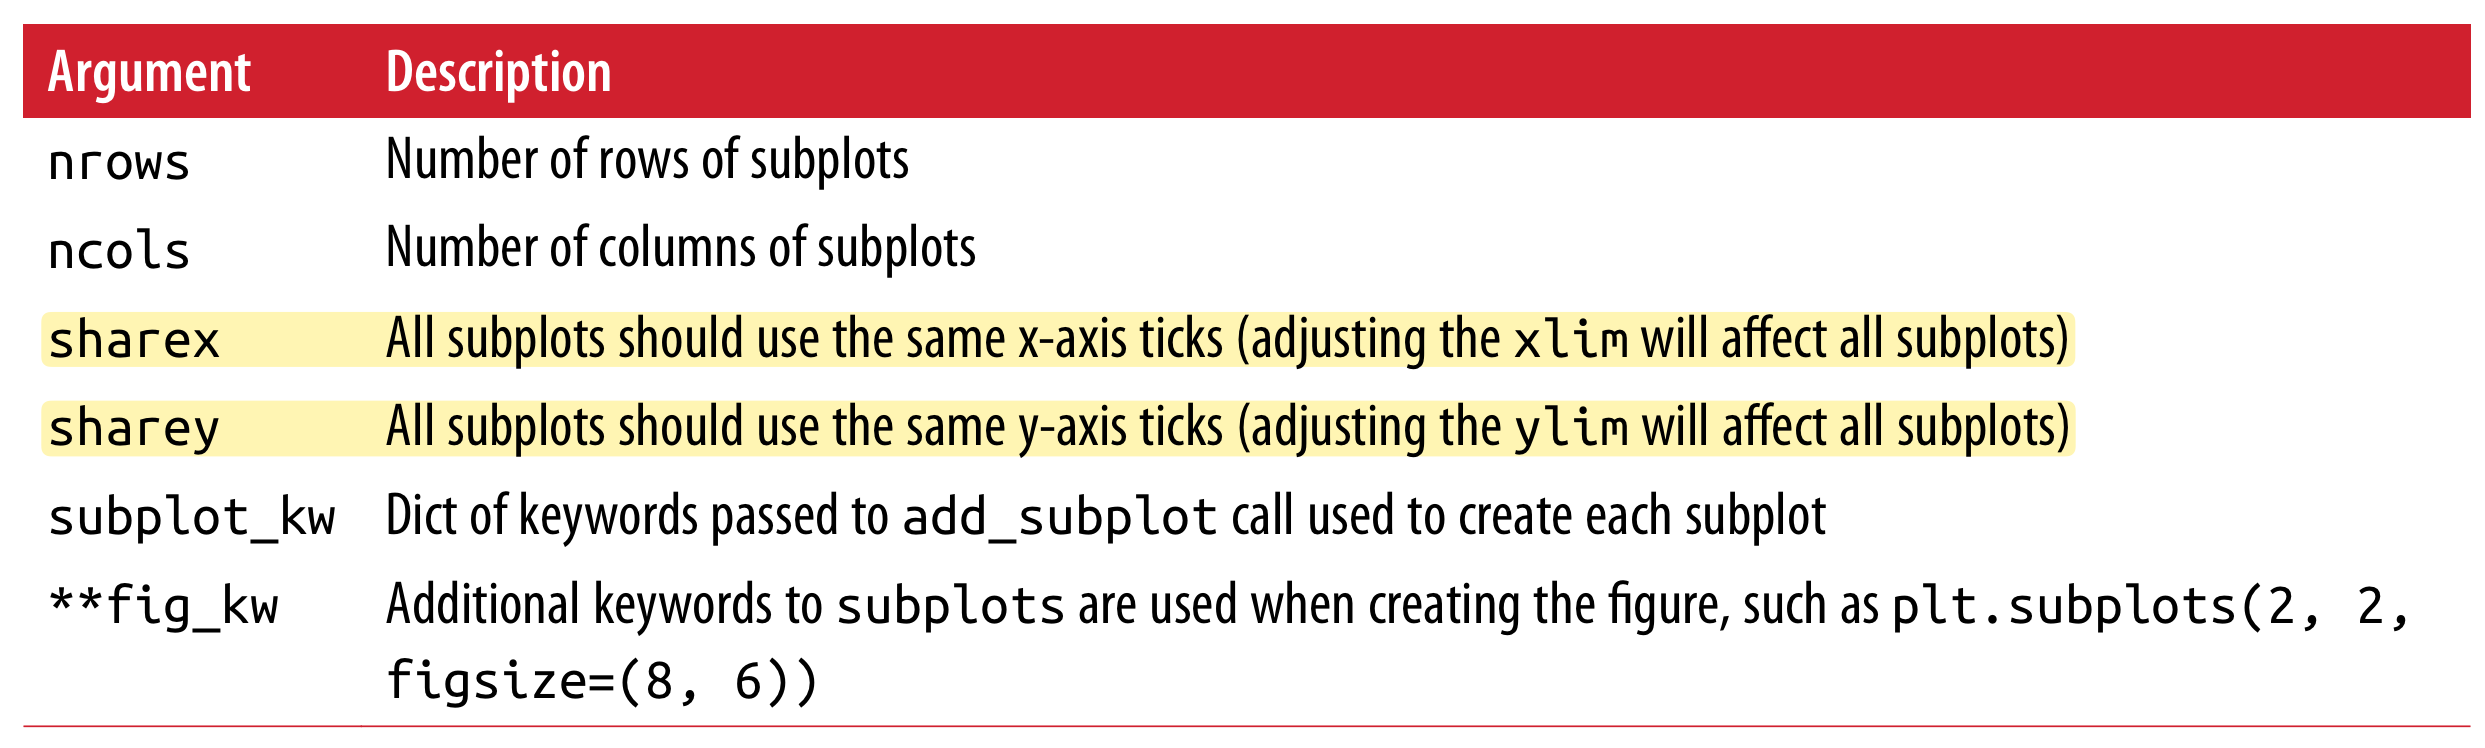

### Adjusting the spacing around subplots
- You can change the spacing using the ***subplots_adjust*** method on **Figure** objects, also available as a top-level function:
- ***subplots_adjust(left= , bottom= , right= , top=, wspace=, hspace= )***
- ***wspace*** and ***hspace*** controls the percent of the figure width and figure height, respectively, to use as spacing between subplots.

<IPython.core.display.Javascript object>


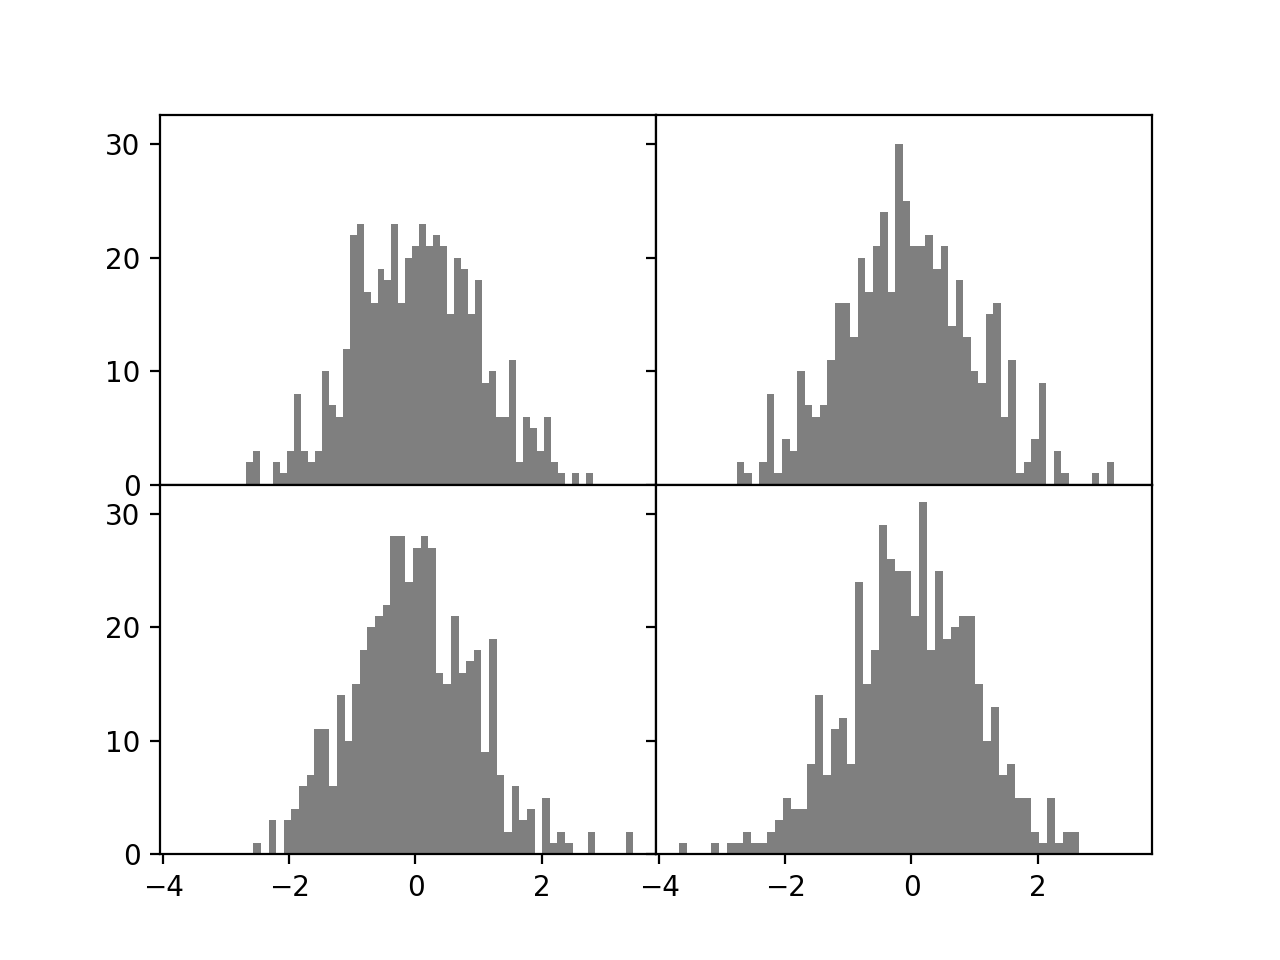

In [36]:
fig, axes = plt.subplots(2,2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i,j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0)

### Colors, Markers, and Line Styles

> - For line plots, you will notice that subsequent points are linearly interpolated by default. This can be altered with the ***drawstyle*** option

In [3]:
data = np.random.randn(30).cumsum()

<IPython.core.display.Javascript object>


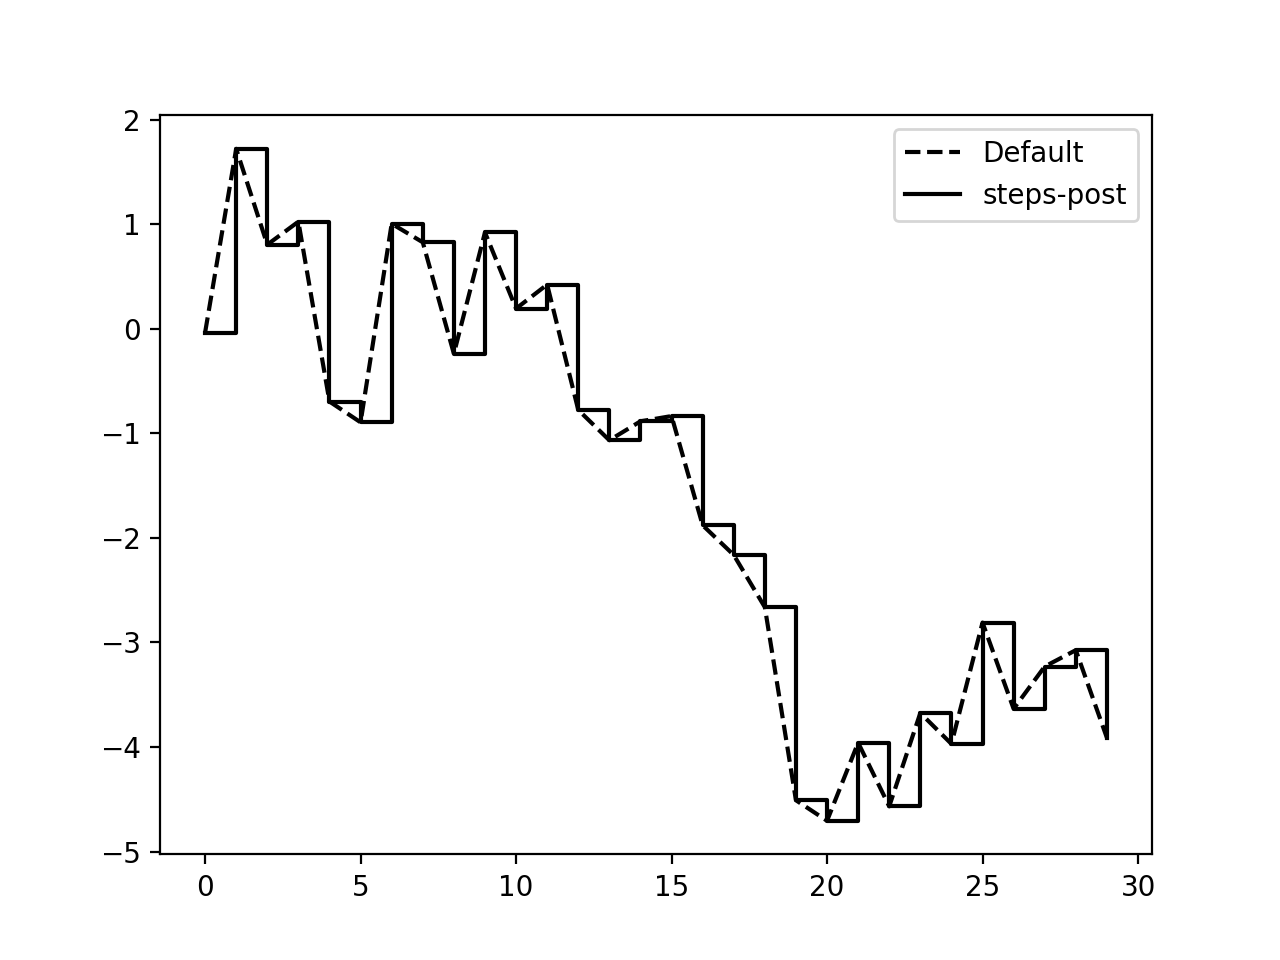

In [4]:
plt.plot(data, 'k--', label='Default')

In [5]:
plt.plot(data, 'k-', drawstyle='steps-post', label='steps-post')

In [6]:
plt.legend(loc='best')

### Ticks, Labels, and Legends
- There are two main ways: using the procedural **pyplot interface** and the more object-oriented **native matplotlib API**.

- 1. pyplot interface
    > - Called with no arguments returns the current parameter value(e.g., ***plt.xlim()*** returns the current x-axis plotting range
    > - Called with parameters sets the parameter value (e.g., ***plt.xlim([0,10])***, sets the x-axis range to 0 to 10)
    > - All such methods act on the active or most recently created *AxesSubplot*.

- 2. Subplot object itself = Subplot instance methods
    > - ***ax.get_xlim***
    > - ***ax.set_xlim***
    > - 해당 방법을 더 자주 사용해볼 것: 여러 subplot 사용 시 유리

#### Setting the title, axis labels, ticks, and ticklabels

<IPython.core.display.Javascript object>


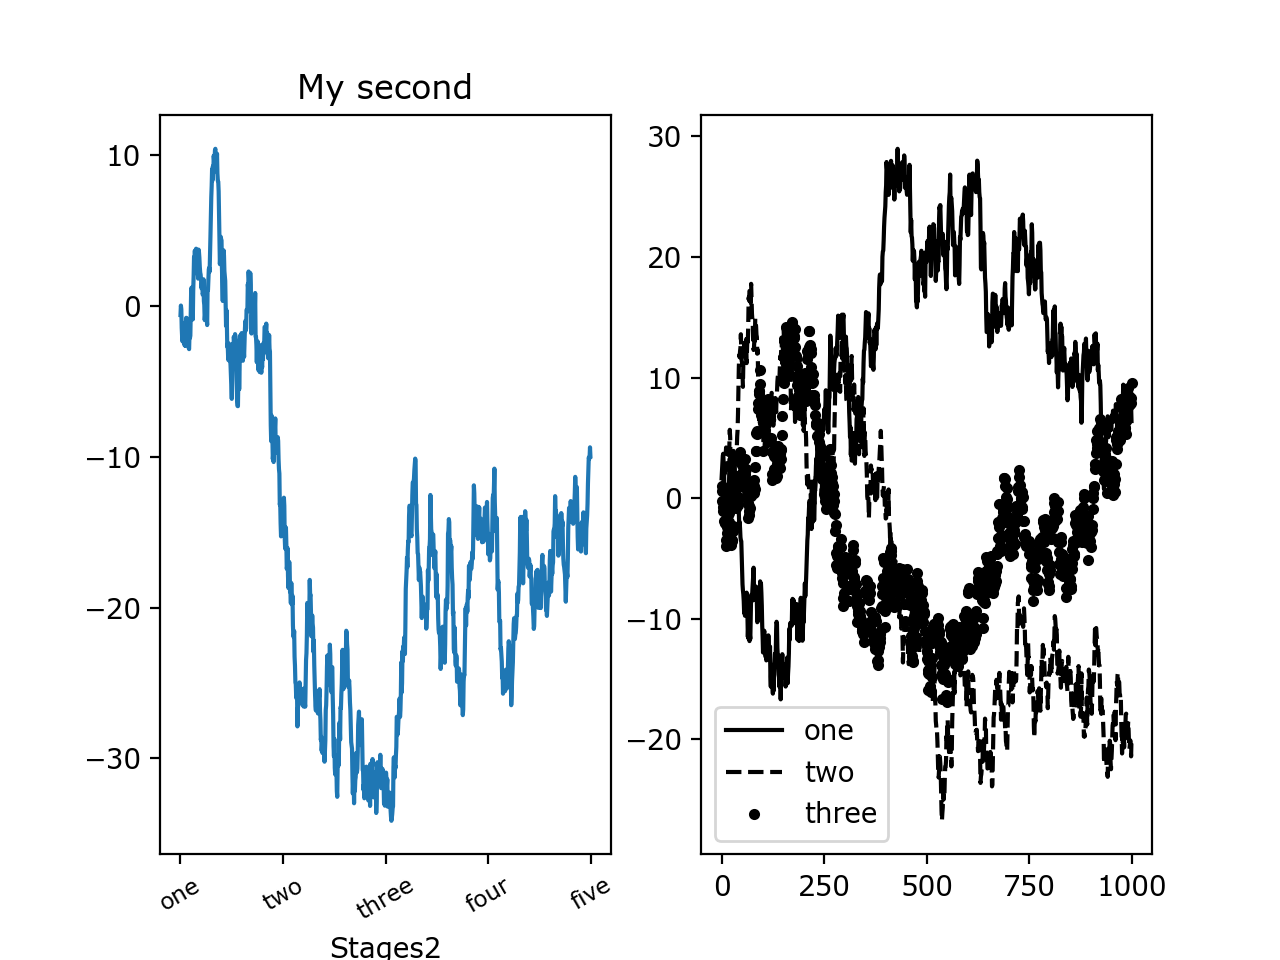

In [3]:
fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.plot(np.random.randn(1000).cumsum())

> - ***set_xticks*** : Instructing matplotlib where to place the ticks along the data range; by default these locations will also be the labels
> - ***set_xticklabels*** : Setting any other values as the labels

In [4]:
ticks = ax.set_xticks([0,250,500,750,1000])

In [5]:
labels = ax.set_xticklabels(['one','two','three','four','five'], rotation=30, fontsize='small')

In [6]:
ax.set_xlabel('Stages')

Text(0.5, 24.313360157402354, 'Stages')

In [7]:
ax.set_title('My first')

Text(0.5, 1.0, 'My first')

- Modifying the y-axis consists of the same process, substituting y for x in the above.

> - The axes class has a ***set*** method that allows **batch** setting of plot properties.

In [8]:
props = {'title': 'My second', 'xlabel':'Stages2'}
ax.set(**props)

[Text(0.5, 1.0, 'My second'), Text(0.5, 24.313360157402354, 'Stages2')]

#### Adding legends

In [9]:
from numpy.random import randn
ax2 = fig.add_subplot(1,2,2)
ax2.plot(randn(1000).cumsum(), 'k', label='one')

In [10]:
ax2.plot(randn(1000).cumsum(), 'k--', label='two')

In [11]:
ax2.plot(randn(1000).cumsum(), 'k.', label='three')

In [12]:
ax2.legend(loc='best') # = plt.legend()

- To exclude one or more elements from the legend, pass no label or ***label='\_nolegend\_'***

### Annotations and Drawing on a Subplot
- ***text, arrow*** and ***annotate*** function

> - ***text*** draws text at given coordinates(x,y) on the plot with optional custom styling
> - The ***ax.annotate*** method can draw labels at the indicated x and y coordinates.

<IPython.core.display.Javascript object>


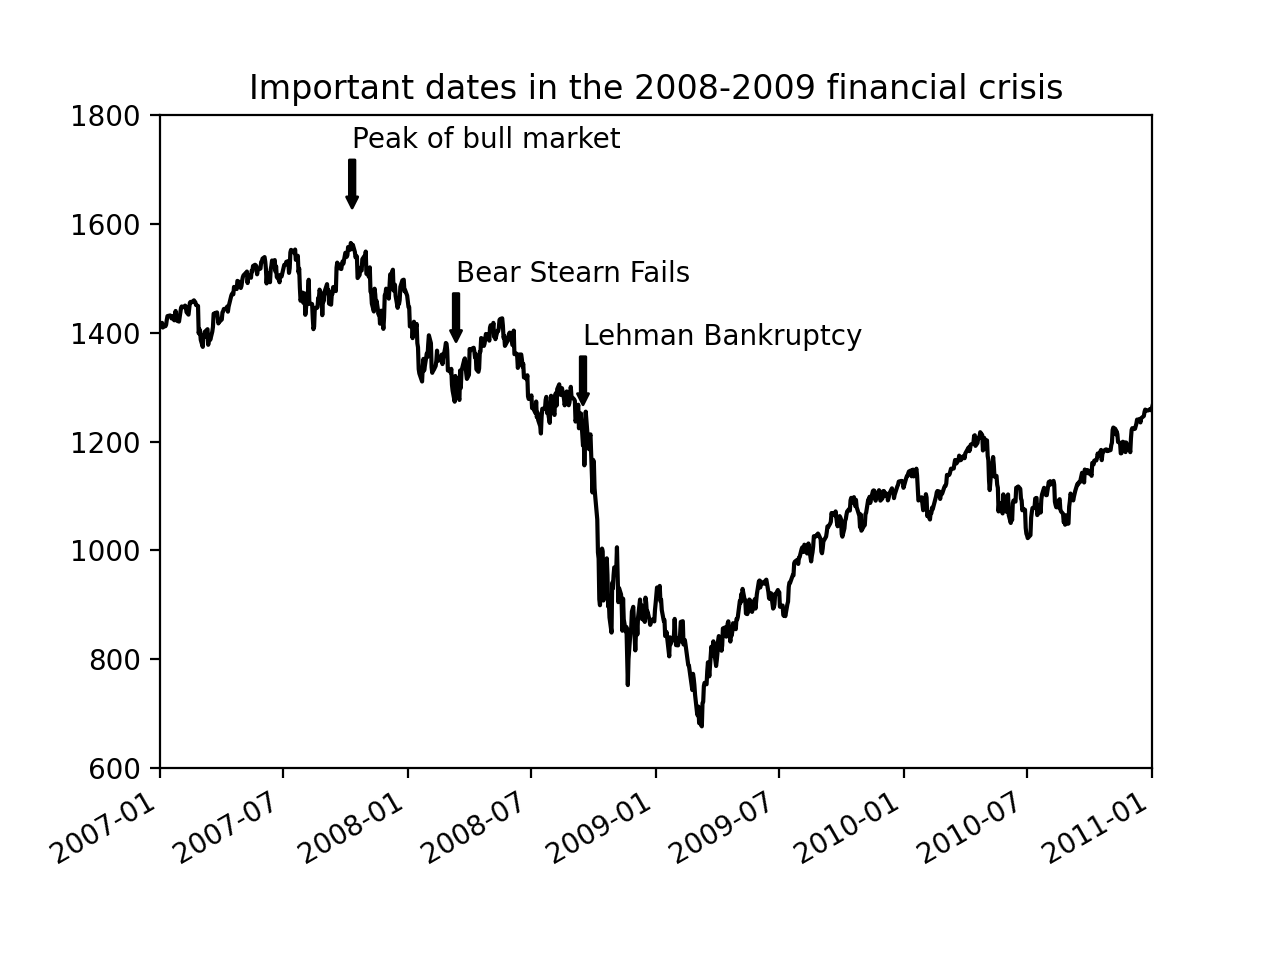

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

In [18]:
from datetime import datetime

fig = plt.figure()
ax4 = fig.add_subplot(1,1,1)

data = pd.read_csv('Examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']

spx.plot(ax=ax4, style='k-')

crisis_data = [
    (datetime(2007,10,11), 'Peak of bull market'),
    (datetime(2008,3,12), 'Bear Stearn Fails'),
    (datetime(2008,9,15), 'Lehman Bankruptcy')
]

for date, label in crisis_data:
    ax4.annotate(label, xy=(date, spx.asof(date)+75),
                xytext=(date, spx.asof(date)+225),
                arrowprops=dict(facecolor='black', headwidth=4, width=2, headlength=4),
                horizontalalignment='left', verticalalignment='top')

# Zoom in on 2007-2010
ax4.set_xlim(['1/1/2007', '1/1/2011'])
ax4.set_ylim([600, 1800])

ax4.set_title('Important dates in the 2008-2009 financial crisis')

#ax4.plot(np.random.randn(1000).cumsum())
#ax4.text(200,10, 'Hello World!')

> - matplotlib has objects that represent many common shapes, referred to as *patches*. Some of these, like ***Retangle*** and ***Circle***, are found in ***matplotlib.pyplot***, but the full set is located in ***matplotlib.patches***. 

<IPython.core.display.Javascript object>


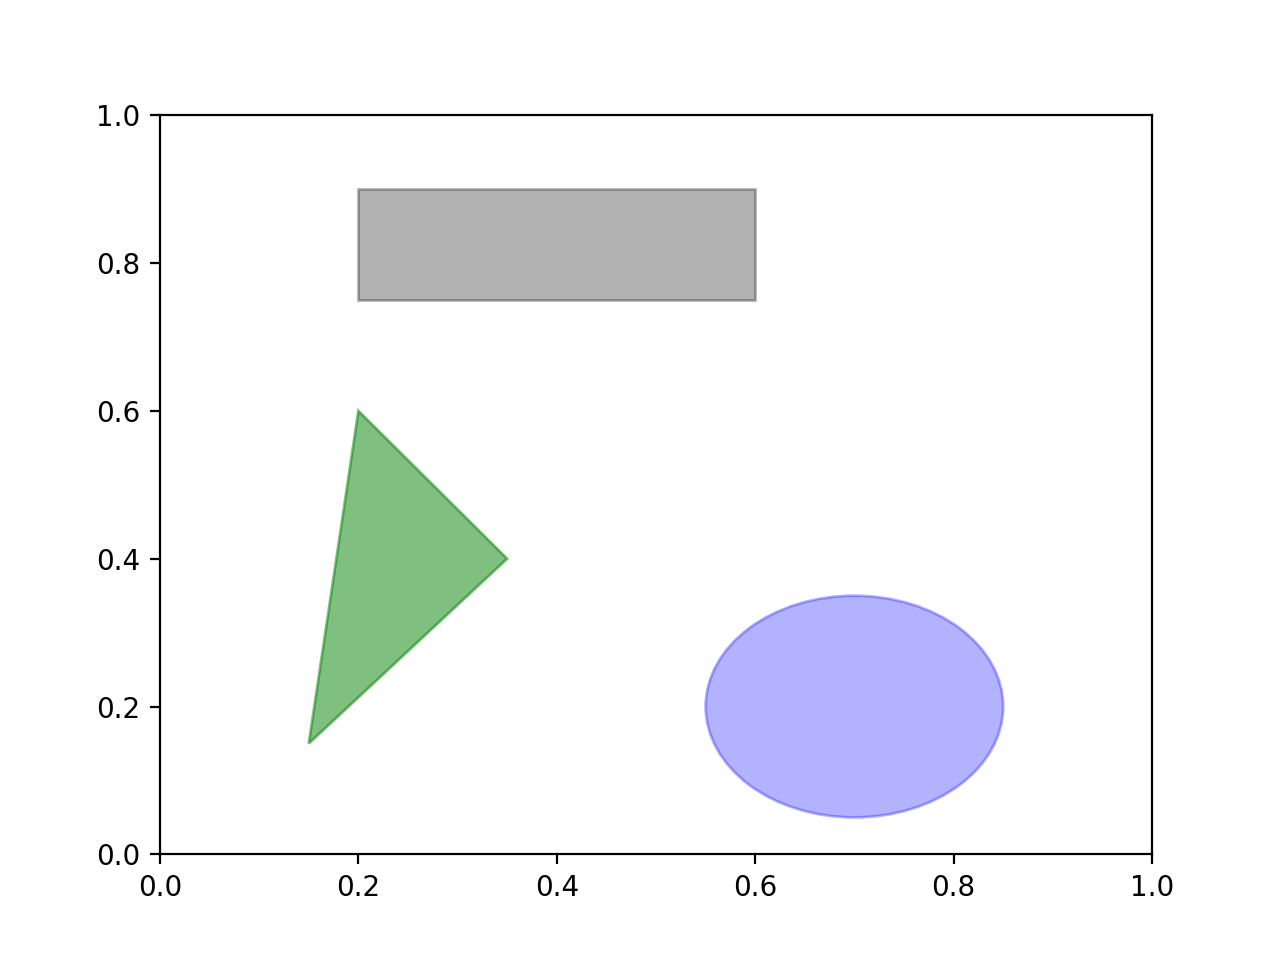

In [21]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

rect = plt.Rectangle((0.2,0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7,0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15,0.15],[0.35,0.4],[0.2,0.6]], color='g', alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

### Saving Plots to File
- You can save the active figure to file using ***plt.savefig('filename')***. This method is equivalent to the figure object's ***savefig*** instance method.
>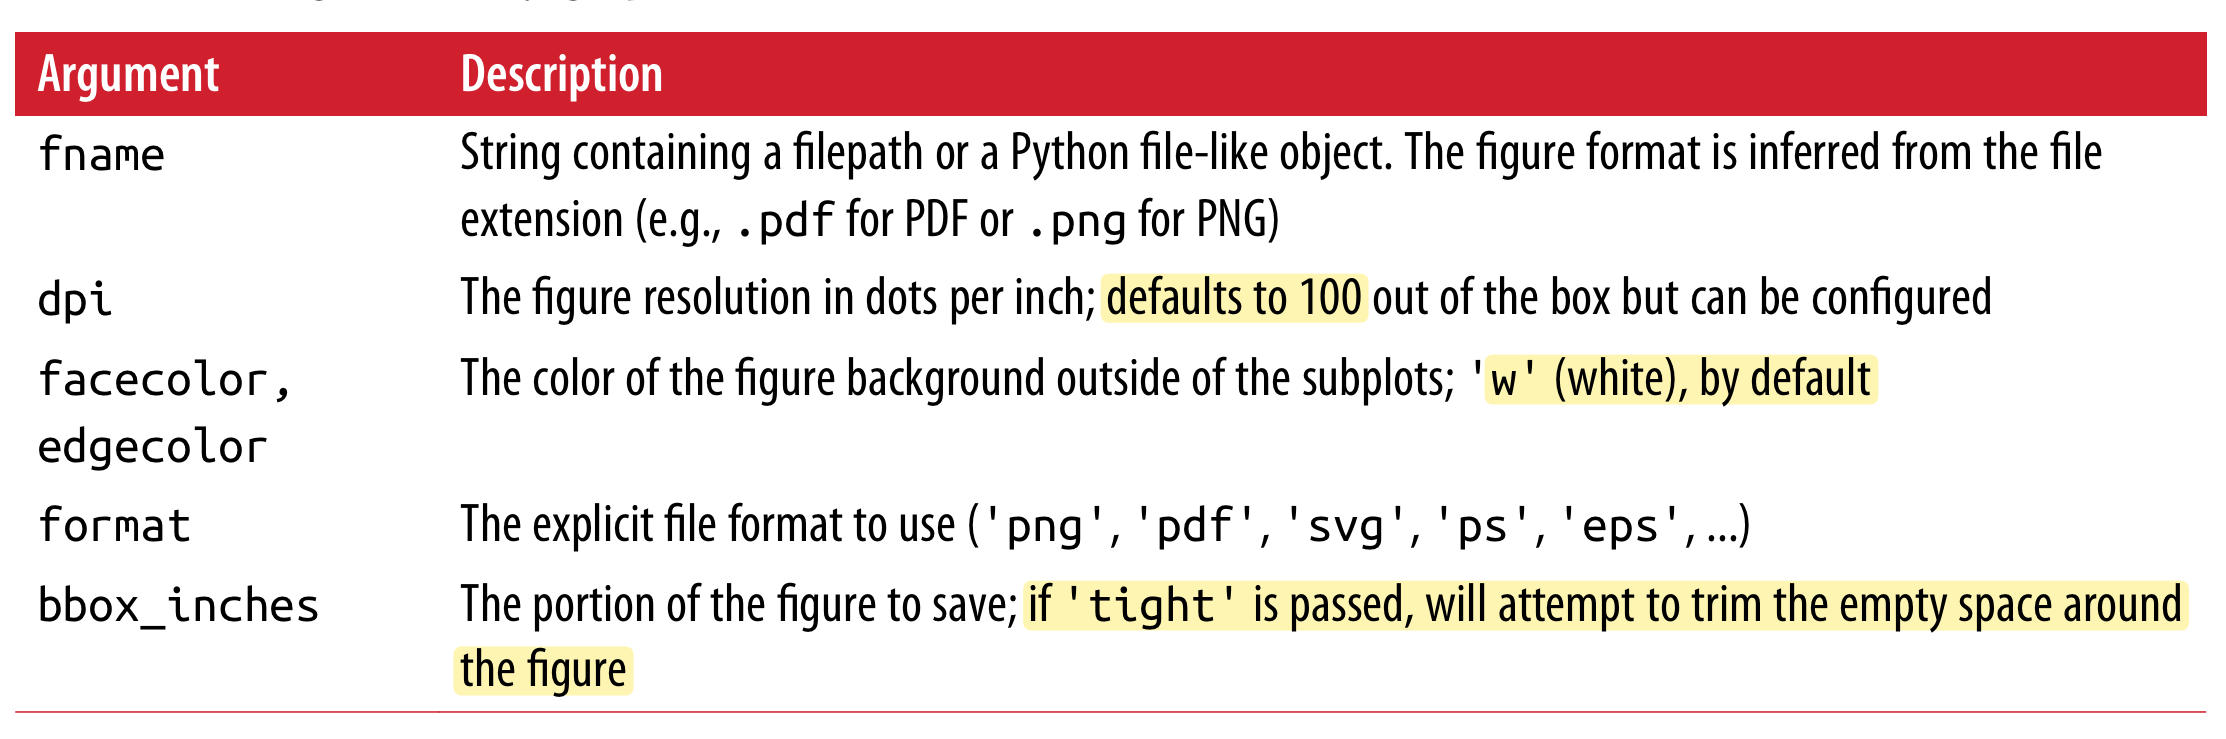

### matplotlib Configuration (Skip)
- One way to modify the configuration programmatically from Python is to use the ***rc*** method
- For extensive customization and to see a list of all the options, matplotlib comes with a configuration file ***maplotlibrc*** in the ***matplotlib/mpl-data*** directory
- If you customize the file and place it in your home directory titled ***.matplotlibrc***, it will be loaded each time you use maplotlib
- The ***seaborn*** package has several built-in plot themes or styles that use matplotlib's configuration system internally.

## 9.2 Plotting with pandas and seaborn

### Line Plots
- Series and DataFrame each have a ***plot*** attribute for making som basic plot types
- By default, ***plot()*** makes line plots

<IPython.core.display.Javascript object>


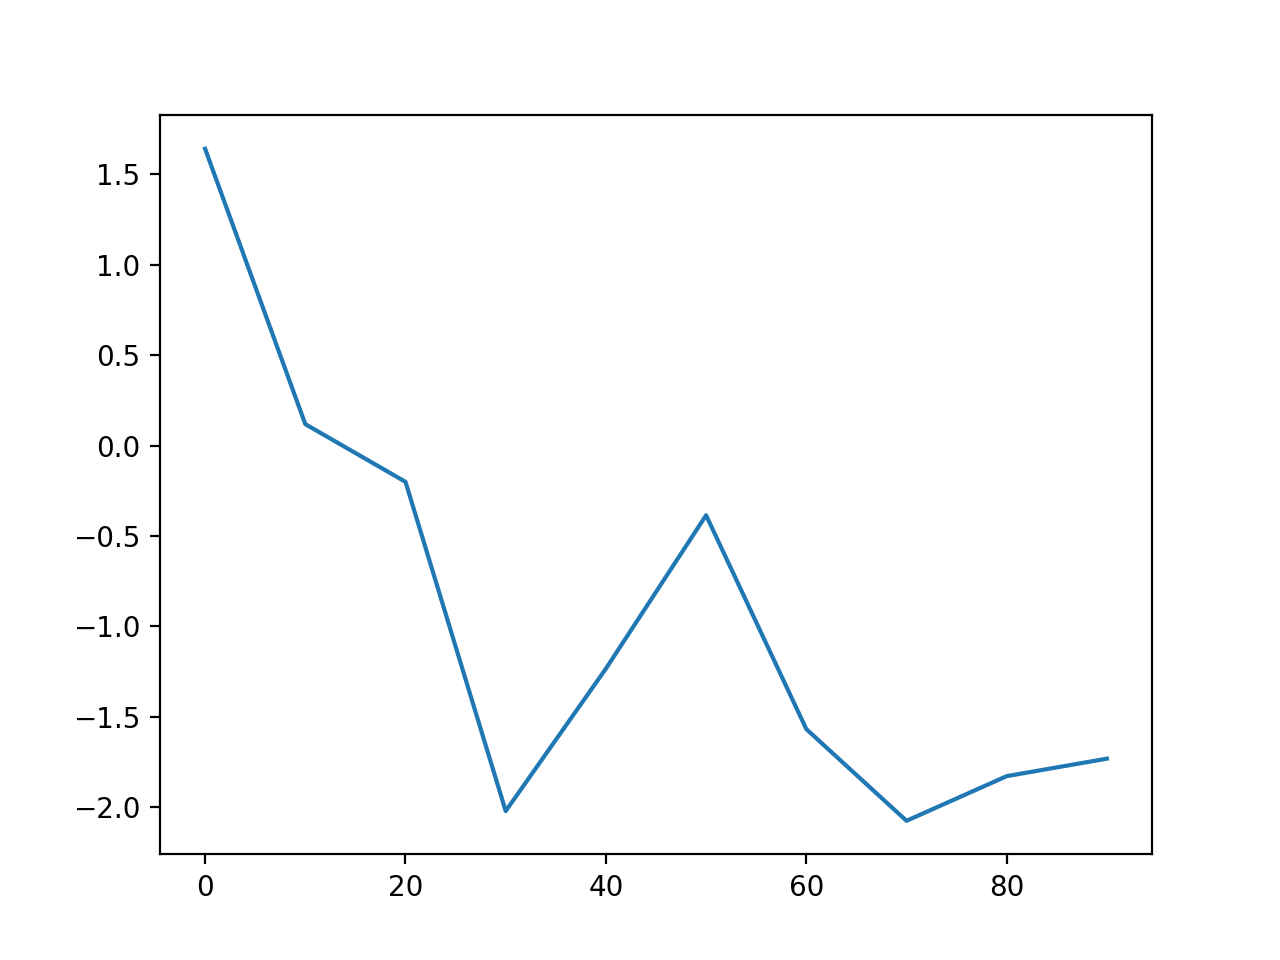

<AxesSubplot:>

In [3]:
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0,100,10))
s.plot()

> 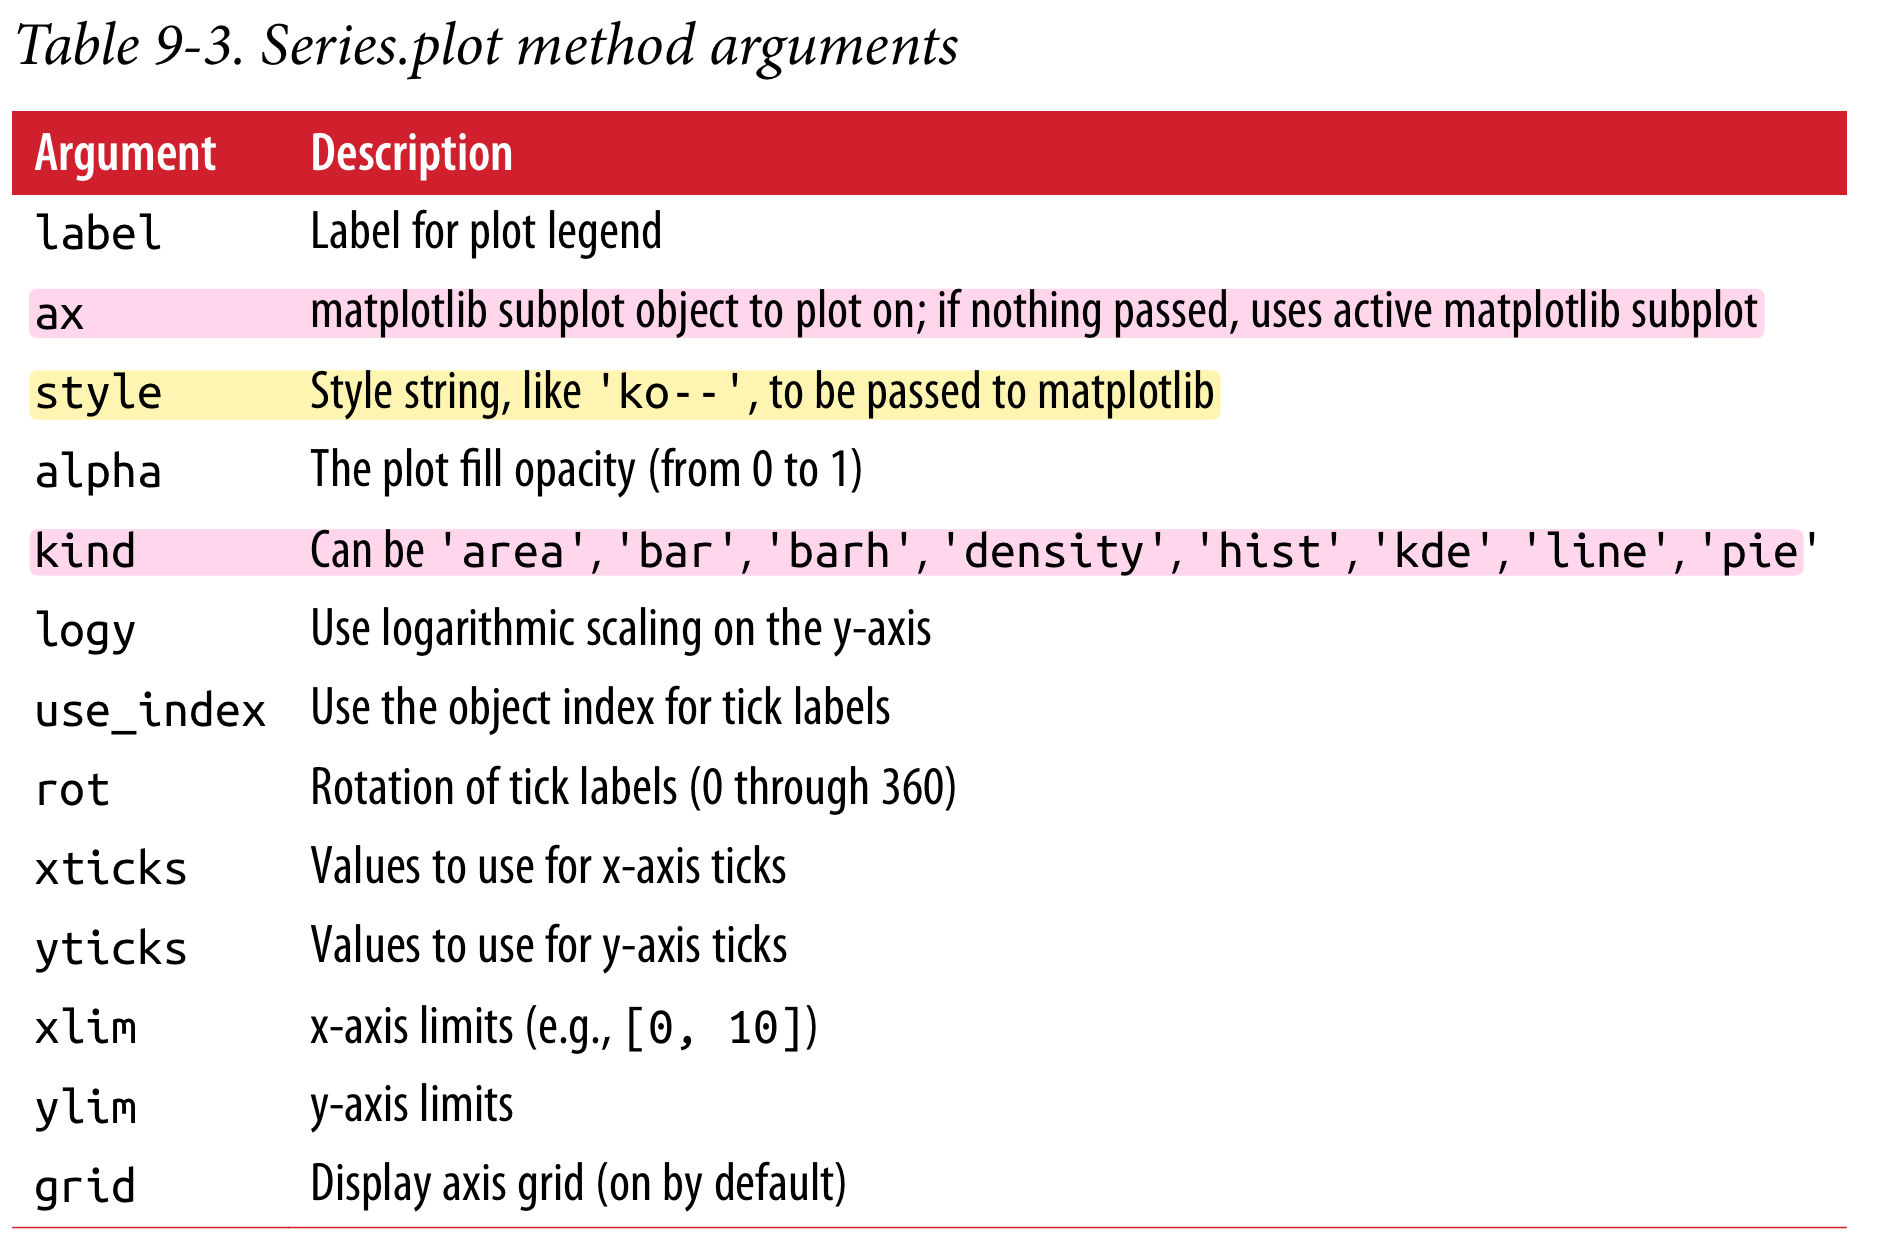

> - DataFrame has a number of options allowing some flexibility with how the columns are handling, whether **to plot them all on the same subplot or to create separate subplots**:
> 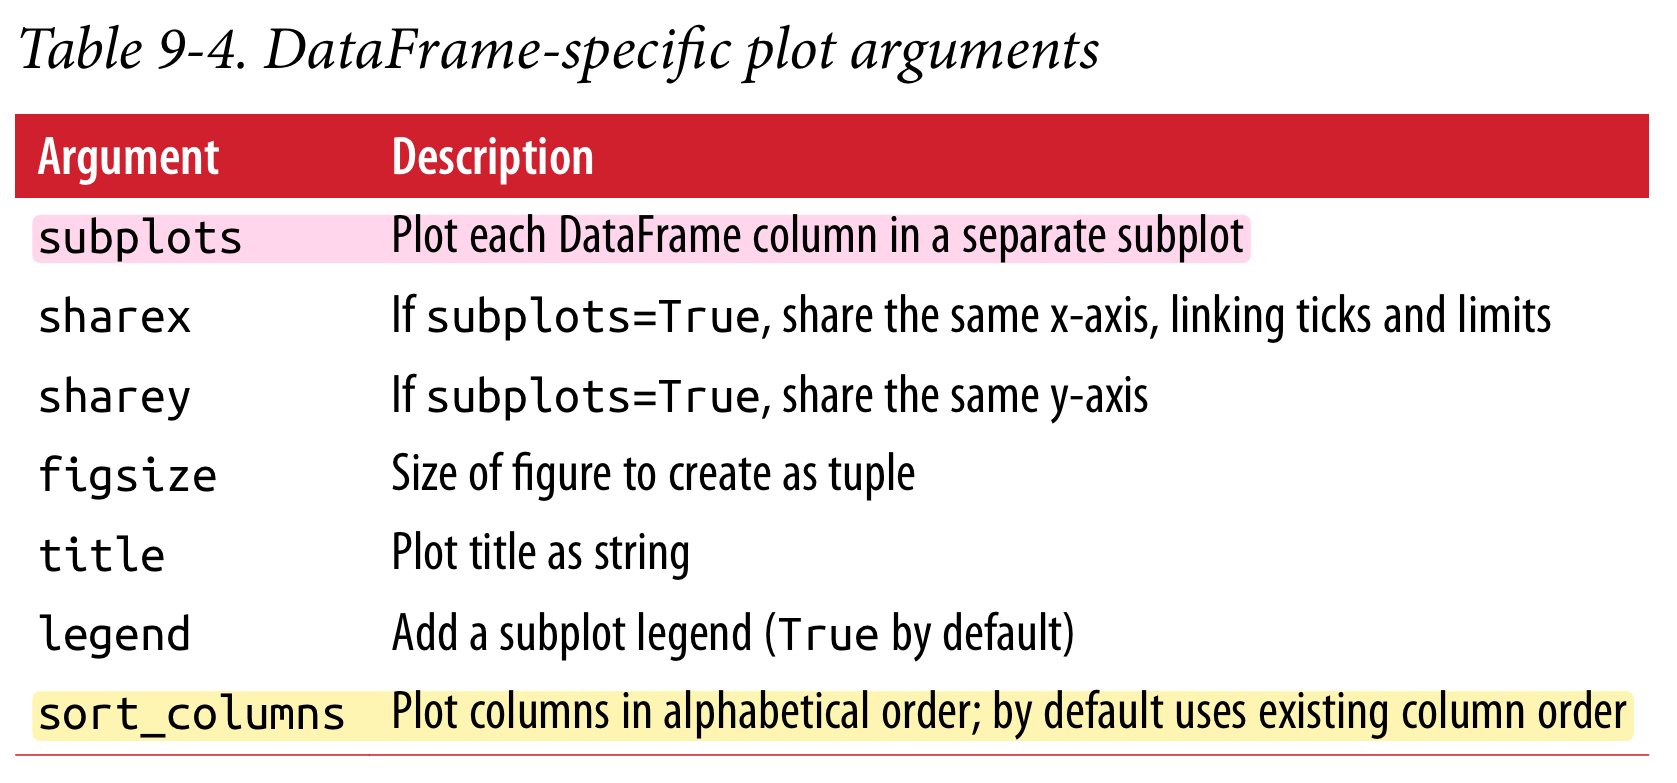

<IPython.core.display.Javascript object>


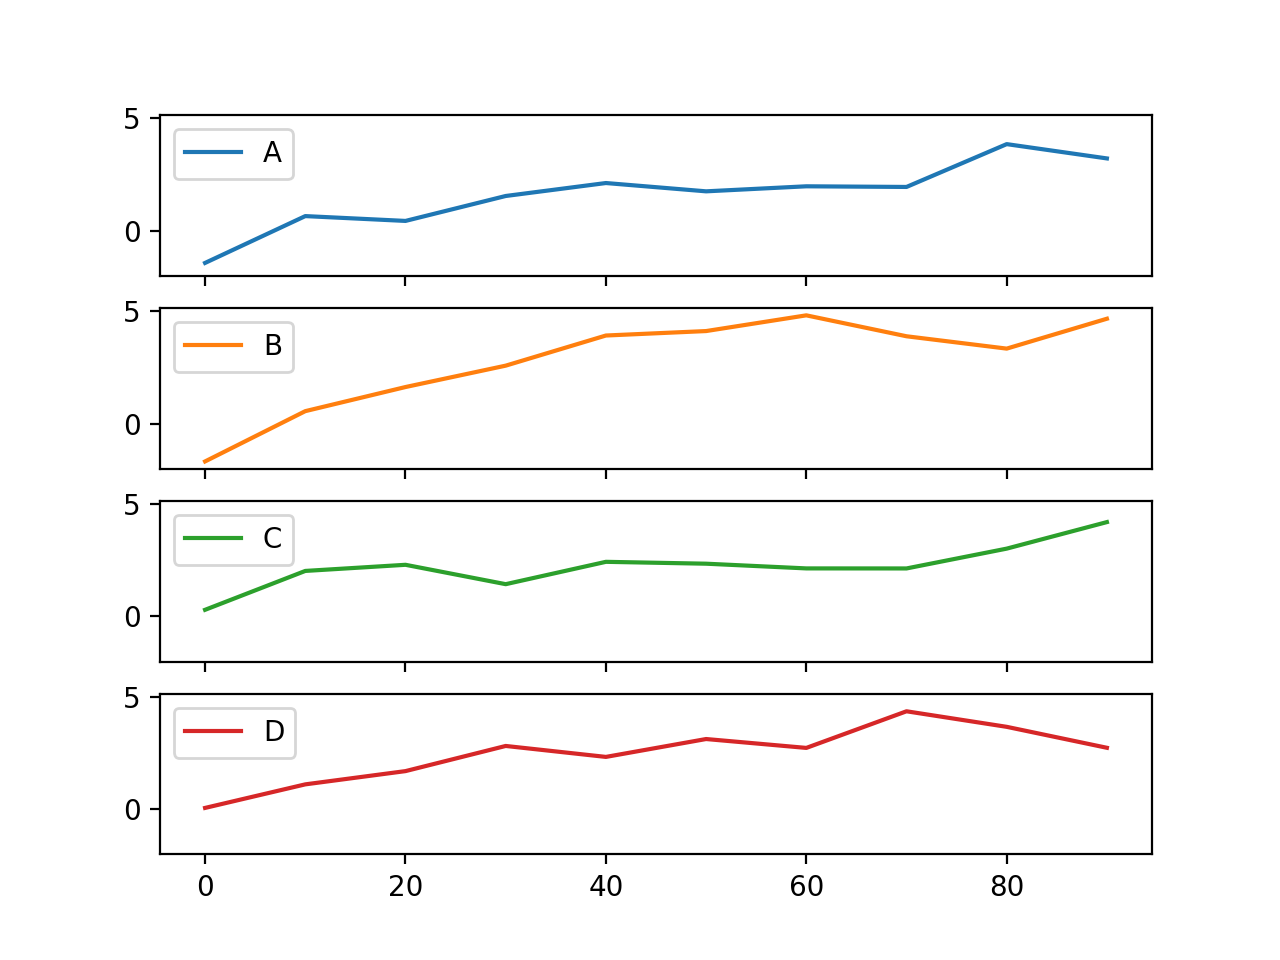

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
      dtype=object)

In [9]:
df = pd.DataFrame(np.random.randn(10,4).cumsum(0), columns=['A','B','C','D'],
                  index=np.arange(0,100,10))
df.plot(subplots=True, sharey=True) # = df.plot.line()

### Bar Plots

> - With a DataFrame, bar plots group the values in each row together in a group in bars
> - Stacked bar plots are created from a DataFrame by passing ***stacked=True***, resulting in the value in each row being stacked together

In [5]:
df = pd.DataFrame(np.random.rand(6,4), index=['one','two','three','four','five','six'],
                  columns=pd.Index(['A','B','C','D'], name='Genus'))
df

Genus,A,B,C,D
one,0.687290,0.758527,0.935360,0.886157
two,0.220569,0.180521,0.156748,0.995444
three,0.945573,0.363752,0.518853,0.126830
four,0.597902,0.951933,0.232327,0.083431
five,0.104273,0.406947,0.698749,0.350776
six,0.981891,0.477810,0.224134,0.885840


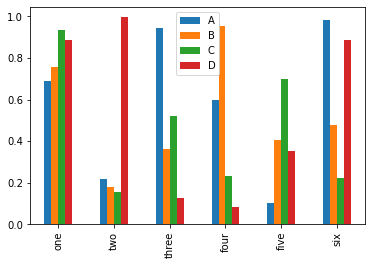

In [6]:
df.plot(kind='bar').legend(loc='best')

In [7]:
tips = pd.read_csv('Examples/tips.csv')

In [8]:
party_counts = pd.crosstab(tips['day'], tips['size'])
# not many 1- and 6- person paties
party_counts = party_counts.loc[:, 2:5]
party_counts

size,2,3,4,5
day,,,,
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3
Thur,48,4,5,1


In [9]:
# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(1), axis=0)
party_pcts

size,2,3,4,5
day,,,,
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000
Thur,0.827586,0.068966,0.086207,0.017241


<AxesSubplot:xlabel='day'>

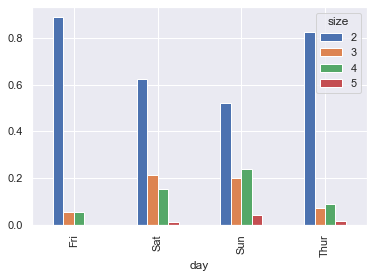

In [24]:
party_pcts.plot.bar()

> - With data that requires aggregation or summarization before making a plot, using the **seaborn** package can make things much simpler

In [2]:
import seaborn as sns

In [12]:
tips['tip_pct'] = tips['tip'] / (tips['total_bill']-tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


> - ***seabron.barplot*** has a ***hue*** option that enables us to split by an additional categorical value:
> - You can switch between different plot appearances using ***seaborn.set***:

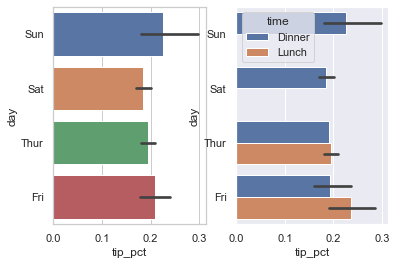

In [23]:
sns.set(style="whitegrid")
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1 = sns.barplot(x='tip_pct', y='day', data=tips, orient='h')

sns.set(style="darkgrid")
ax2 = fig.add_subplot(1,2,2)
ax2 = sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

- Plotting functions in seaborn take a ***data*** argument, which can be a pandas DataFrame. The other arguments refer to column names. 
- Because there are multiple observations for each value in the **day**, the bars are the average value of **tip_pct**.
- The black lines drawn on the bars represent the **95% confidence interval** (optional arguments로 수정 가능).

### Histograms and Density Plots
- A histogram is a kind of bar plot that gives a discretized display of value frequency.

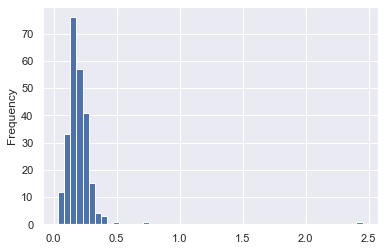

In [25]:
fig2 = plt.figure()
fig2 = tips['tip_pct'].plot.hist(bins=50)

> - A related plot type is a *density plot*, which is formed by computing an estimate of a continuous probability distribution that might have generated the observed data.
> - The usual procedure is to approximate this distribution as a mixture of "kernels"-that is, simpler distributions like the **normal distribution**.
> - Thus, density plots are also known as **kernel density estimate (KDE) plots**.
> - Using ***plot.kde*** makes a density plot using the conventional mixture-of-normals estimate

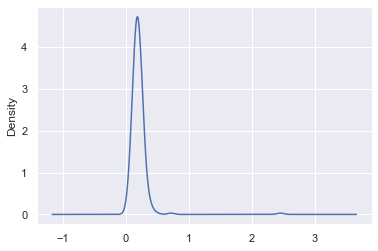

In [26]:
fig3 = plt.figure()
fig3 = tips['tip_pct'].plot.density()

> - Seaborn makes histograms and density plots even easier through its ***distplot*** method, which can plot both a histogram and a continuous density estimate simultaneously. 

In [27]:
comp1 = np.random.normal(0,1, size=200)

In [28]:
comp2 = np.random.normal(10,2, size=200)

In [29]:
values = pd.Series(np.concatenate([comp1, comp2]))
values

0       0.208448
1       0.268893
2       1.460149
3       0.463236
4       0.267146
         ...    
395    12.180424
396     5.347350
397    12.472252
398    11.755932
399    10.892841
Length: 400, dtype: float64

<AxesSubplot:ylabel='Density'>

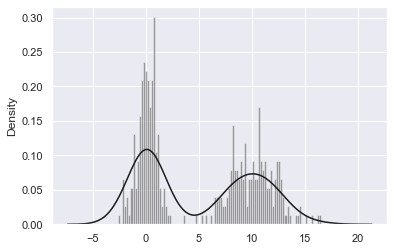

In [31]:
sns.distplot(values, bins=100, color='k')

### Scatter or Point Plots
- Point plots or scatter plots can be a useful way of examining the relationship between two one-dimensional data series.

In [5]:
macro = pd.read_csv('Examples/macrodata.csv')
data = macro[['cpi','m1','tbilrate','unemp']]

trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


> - seaborn's ***regplot*** method, which makes a scatter plot and fits a linear regression line

Text(0.5, 1.0, 'Change in log(m1) versus los(unemp)')

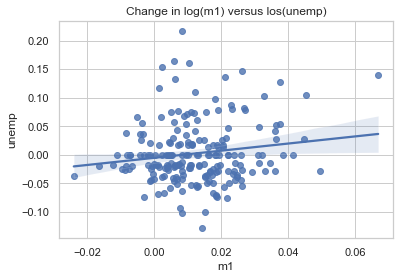

In [6]:
sns.set(style="whitegrid")
sns.regplot(x='m1', y='unemp',data=trans_data)
plt.title('Change in log(m1) versus los(unemp)')

> - In exploratory data analysis, it's helpful to be able to look at all the scatter plots among a group of variables; this is known as a ***pairs*** plot or ***scatter plor matrix***.
> - Seaborn has a convenient ***pairplot*** function, which supports placing histograms or density estimates of each variable along the diagonal:

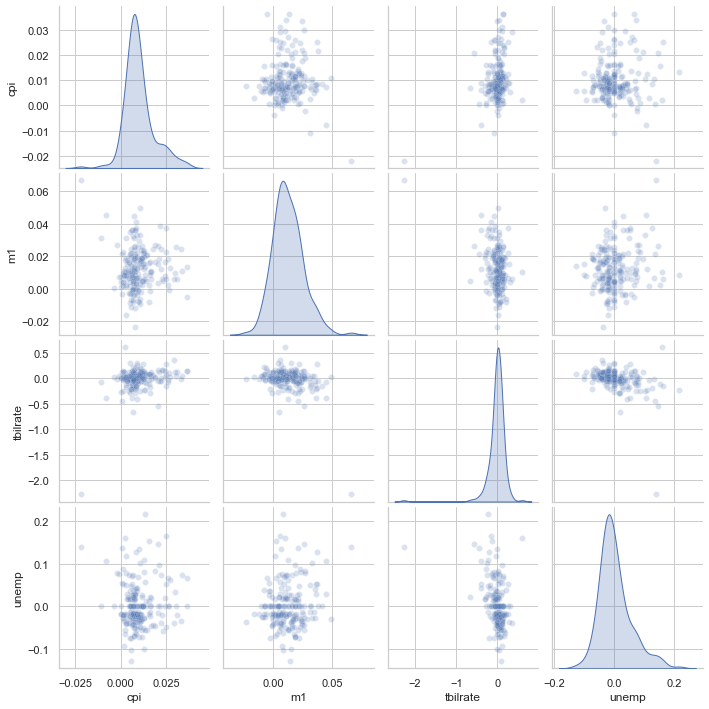

In [7]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha':0.2})

- The ***plot_kws*** argument: This enables us to pass down configuration options to the individual plotting calls **on the off-diagonal elements**.

### Facet Grids and Categorical Data
- One way to visualize data with many categorical variables is to use a **facet grid**.
- Seaborn has a useful built-in function ***catplot*** that simplifies making many kinds of faceted plots

In [4]:
tips = pd.read_csv('Examples/tips.csv')
tips['tip_pct'] = tips['tip'] / (tips['total_bill']-tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


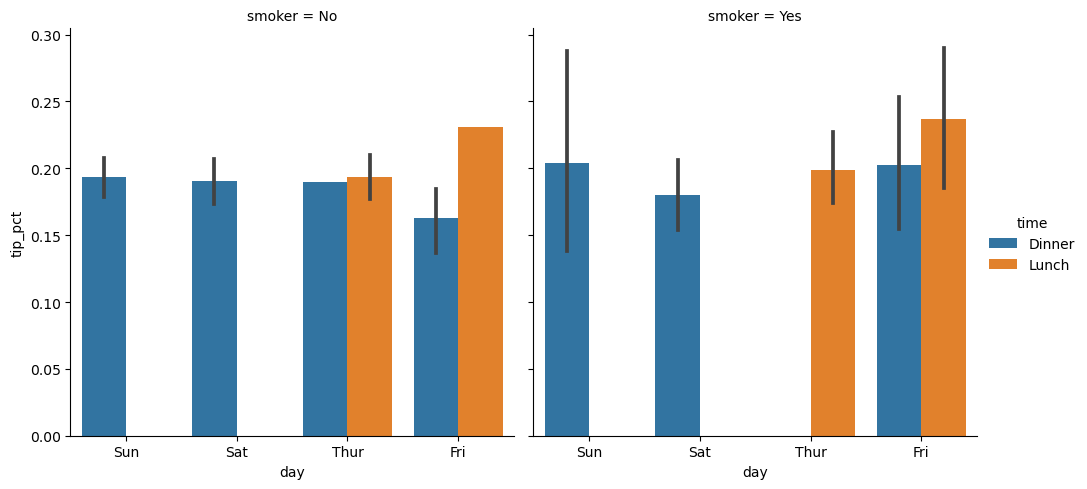

In [6]:
sns.catplot(x='day', y='tip_pct', hue='time', col='smoker', 
               kind='bar', data=tips[tips.tip_pct<1])

> - Instead of grouping by 'time' by different bar colors within a facet, we can also expand the facet grid by adding one row per *time* value:

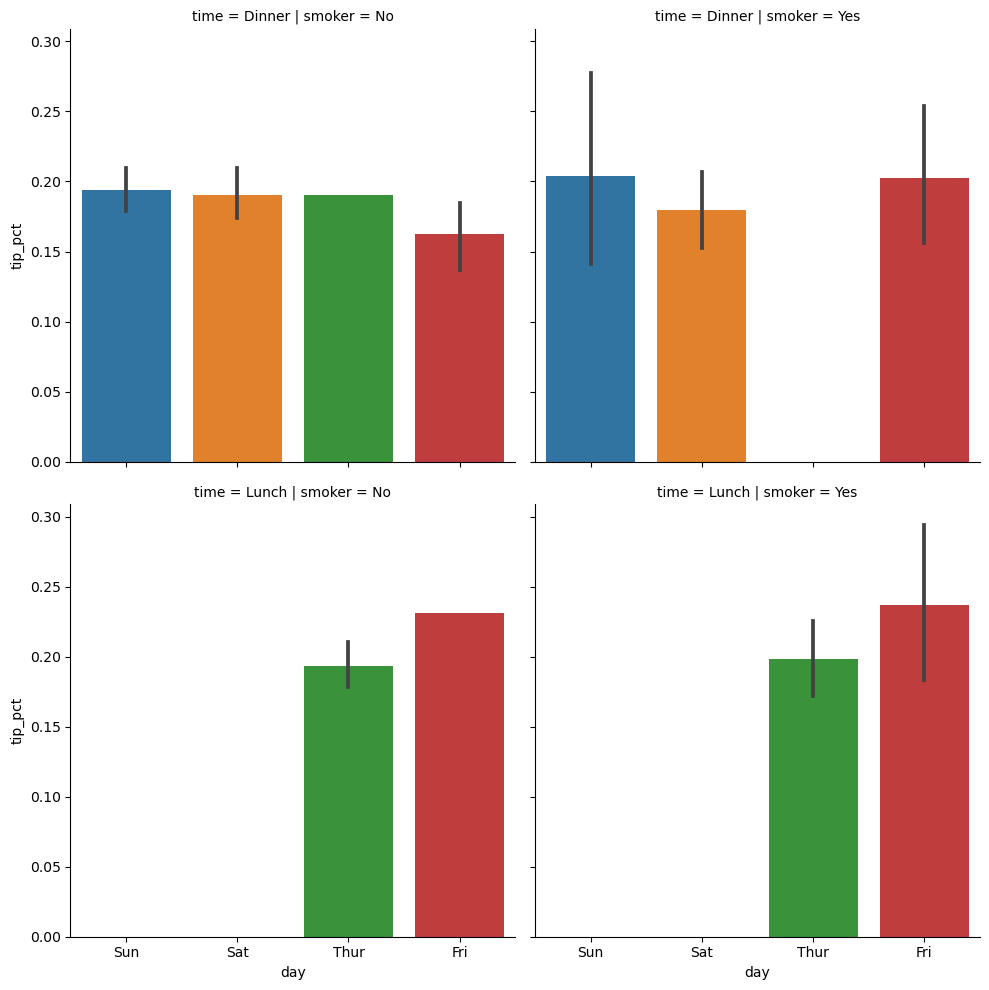

In [8]:
sns.catplot(x='day', y='tip_pct', row='time', col='smoker', 
            kind='bar', data=tips[tips.tip_pct<1])